# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', 500)
pd.options.plotting.backend = "plotly"

# Data

In [2]:
filepath = os.path.join("..","data","processed","validations_fusion.csv")
df = pd.read_csv(filepath)

In [3]:
df.head()

,jour,libelle_arret,id_zdc,categorie_titre,nb_vald,mois,jour_sem_num,id_ref_zdc,nom_zdc,res_com,mode,train,rer,metro,tramway,val,tertrain,terrer,termetro,tertram,terval,exploitant,idf,principal,latitude,longitude,nb_lignes
0,2025-03-07,MADELEINE,71324,Forfaits courts,3387,3,4,71324.0,Madeleine,METRO 8 / METRO 12 / METRO 14,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.870233,2.325164,3.0
1,2025-03-07,BARBES-ROCH.,71426,Autres titres,478,3,4,71426.0,Barbès Rochechouart,METRO 2 / METRO 4,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.883734,2.349525,2.0
2,2025-03-07,S. GAINSBOURG,490779,Contrat Solidarite Transport,781,3,4,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186,1.0
3,2025-03-07,S. GAINSBOURG,490779,Forfait Navigo,2880,3,4,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186,1.0
4,2025-03-07,S. GAINSBOURG,490779,Imagine R,1158,3,4,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186,1.0


In [4]:
df.shape

(1890468, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890468 entries, 0 to 1890467
Data columns (total 27 columns):
 #   Column           Dtype  
---  ------           -----  
 0   jour             object 
 1   libelle_arret    object 
 2   id_zdc           int64  
 3   categorie_titre  object 
 4   nb_vald          int64  
 5   mois             int64  
 6   jour_sem_num     int64  
 7   id_ref_zdc       float64
 8   nom_zdc          object 
 9   res_com          object 
 10  mode             object 
 11  train            float64
 12  rer              float64
 13  metro            float64
 14  tramway          float64
 15  val              float64
 16  tertrain         float64
 17  terrer           float64
 18  termetro         float64
 19  tertram          float64
 20  terval           float64
 21  exploitant       object 
 22  idf              float64
 23  principal        float64
 24  latitude         float64
 25  longitude        float64
 26  nb_lignes        float64
dtypes: float64(1

# Analyses.

## Validations par stations.

In [6]:
# Sélectionner nom station et nombre de validations.
stations_validations_df = df[["nom_zdc","nb_vald"]].copy()

# Grouper par station et somme des validations.
top_stations_df = stations_validations_df.groupby("nom_zdc")["nb_vald"].sum().reset_index()

# Tri pour avoir le top.
top_stations_df = top_stations_df.sort_values(by="nb_vald", ascending=False)

In [7]:
top_stations_df.head()

,nom_zdc,nb_vald
238,Gare Saint-Lazare,82580548
304,La Défense (Grande Arche),56568160
148,Châtelet,52722192
240,Gare de Lyon,48429105
237,Gare Montparnasse,42376168


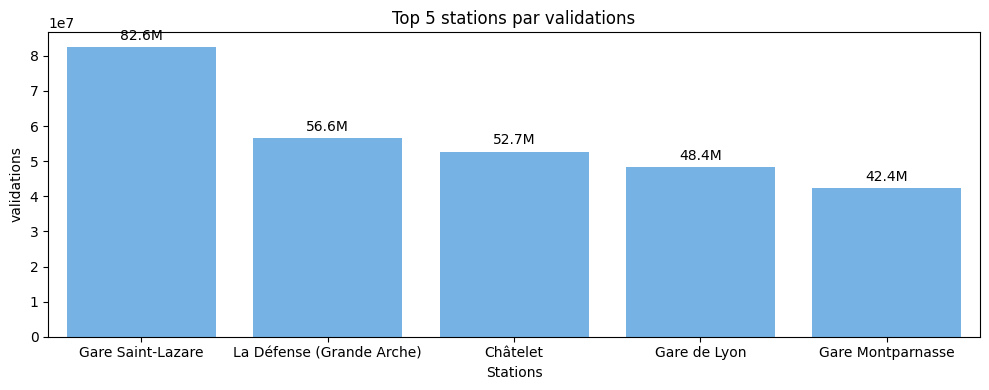

In [8]:
plt.figure(figsize=(10,4))

graph_stations = sns.barplot(top_stations_df.head(), x="nom_zdc", y="nb_vald", color="#64B5F6")

graph_stations.bar_label(
    graph_stations.containers[0],
    fmt=lambda x: f"{x*1e-6:.1f}M",
    padding=3
)

plt.title("Top 5 stations par validations")
plt.xlabel("Stations")
plt.ylabel("validations")
plt.tight_layout()

plt.show()

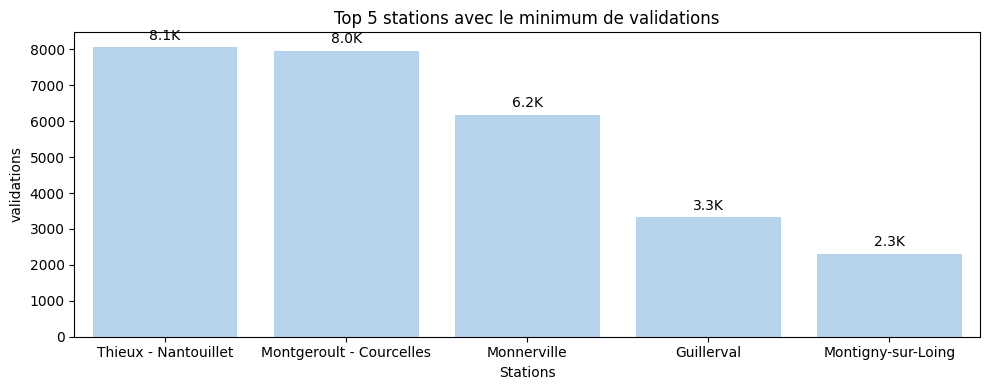

In [9]:
# Stations où il y a moins de validations

plt.figure(figsize=(10,4))

graph_stations_tail = sns.barplot(top_stations_df.tail(), x="nom_zdc", y="nb_vald", color="#ABD4F7")

graph_stations_tail.bar_label(
    graph_stations_tail.containers[0],
    fmt=lambda x: f"{x*1e-3:.1f}K",
    padding=3
)

plt.title("Top 5 stations avec le minimum de validations")
plt.xlabel("Stations")
plt.ylabel("validations")
plt.tight_layout()

plt.show()

## Validations par catégorie de titre.

In [10]:
# Sélectionner catégorie de titre et nombre de validations.
categorie_titre_validations_df = df[["categorie_titre","nb_vald"]].copy()

# Grouper par catégorie de titre et somme des validations.
top_categorie_titre_df = categorie_titre_validations_df.groupby("categorie_titre")["nb_vald"].sum().reset_index()

# Tri pour avoir le top.
top_categorie_titre_df = top_categorie_titre_df.sort_values(by="nb_vald", ascending=False)

In [11]:
top_categorie_titre_df

,categorie_titre,nb_vald
3,Forfait Navigo,1134083245
5,Imagine R,354493868
4,Forfaits courts,337564003
2,Contrat Solidarite Transport,231874519
0,Amethyste,41960259
1,Autres titres,29551454
6,NON DEFINI,27607112


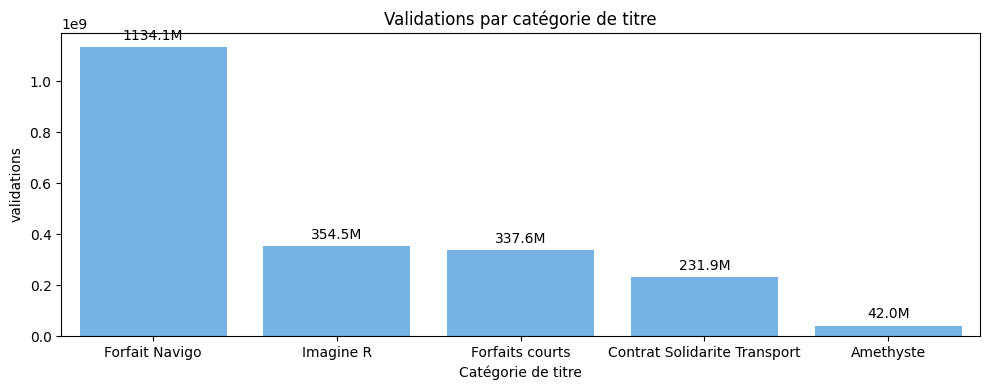

In [12]:
plt.figure(figsize=(10,4))

graph_categorie_titre = sns.barplot(top_categorie_titre_df.head(), x="categorie_titre", y="nb_vald", color="#64B5F6")

graph_categorie_titre.bar_label(
    graph_categorie_titre.containers[0],
    fmt=lambda x: f"{x*1e-6:.1f}M",
    padding=3
)

plt.title("Validations par catégorie de titre")
plt.xlabel("Catégorie de titre")
plt.ylabel("validations")
plt.tight_layout()

plt.show()

## Validations par lignes.

In [13]:
# Somme "nb_vald" pour une ligne donnée.
df[df["res_com"].str.contains("RER B", na=False)]["nb_vald"].sum()

np.int64(190203361)

In [14]:
# Lire csv de validations par ligne.
lignes_filepath = os.path.join("..","data","processed","validations_ligne.csv")
lignes_df = pd.read_csv(lignes_filepath)

In [15]:
lignes_df.head()

,Ligne,somme_nb_vald
0,RER A,324994656
1,RER B,190203361
2,RER C,180974086
3,RER D,191192832
4,RER E,201652557


In [ ]:
# PLOTLY
#fig = px.histogram(lignes_df, x="Ligne", y="somme_nb_vald",)
#fig.update_traces(marker_color='#64B5F6')
#fig

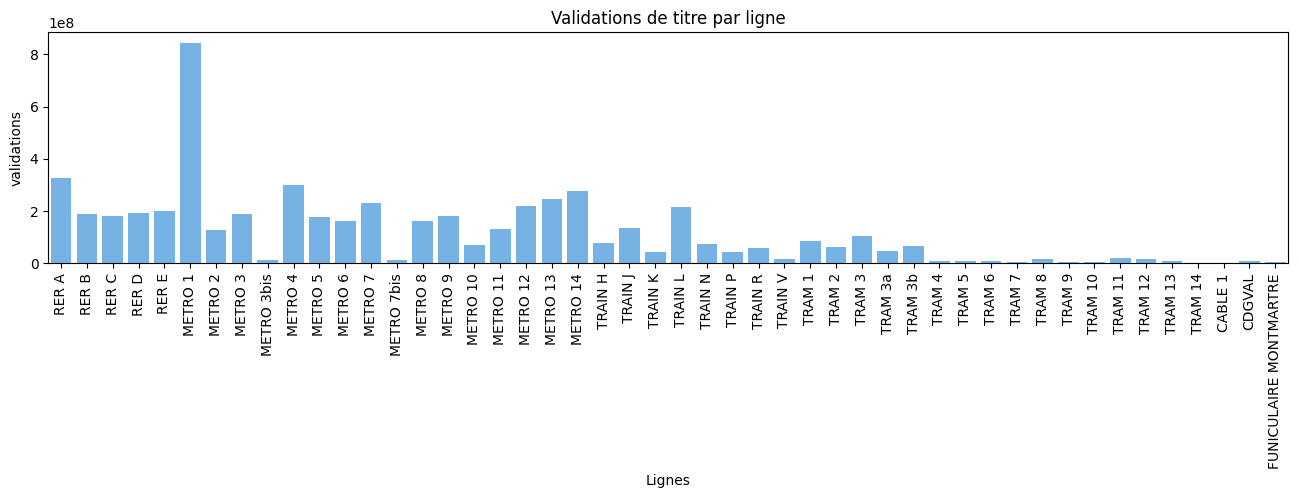

In [16]:
# Validations de titre par ligne.

plt.figure(figsize=(16,3))

sns.barplot(lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

plt.xticks(rotation="vertical")
plt.title("Validations de titre par ligne")
plt.xlabel("Lignes")
plt.ylabel("validations")

plt.show()

In [17]:
# Top lignes.
top_lignes_df = lignes_df.sort_values(by="somme_nb_vald", ascending=False).head()
top_lignes_df

,Ligne,somme_nb_vald
5,METRO 1,842868704
0,RER A,324994656
9,METRO 4,301538185
20,METRO 14,278501830
19,METRO 13,245353261


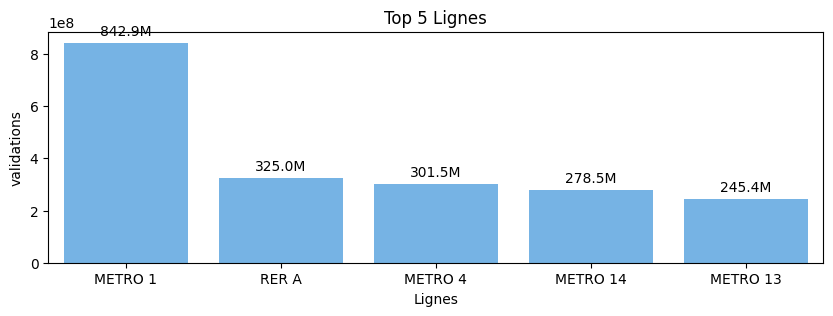

In [18]:
# Top lignes graphique.

plt.figure(figsize=(10,3))

graph_ligne = sns.barplot(top_lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

graph_ligne.bar_label(
    graph_ligne.containers[0],
    fmt=lambda x: f"{x*1e-6:.1f}M",
    padding=3
)

plt.title("Top 5 Lignes")
plt.xlabel("Lignes")
plt.ylabel("validations")

plt.show()

## Scatterplot

In [19]:
# Regroupement par station.
validations_lignes_df = (
    df.groupby("nom_zdc")
    .agg(
        {
            "nb_lignes": "max",
            "nb_vald": "sum"
        }
    )
    .reset_index()
)

In [20]:
validations_lignes_df

,nom_zdc,nb_lignes,nb_vald
0,Abbesses,1.0,2467901
1,Ablon,1.0,598850
2,Achères Grand Cormier,1.0,20422
3,Achères Ville,2.0,1106068
4,Aimé Césaire,1.0,1632922
...,...,...,...
738,Éragny - Neuville,1.0,239929
739,Étienne Marcel,1.0,2466915
740,Étréchy,1.0,206027
741,Évry,1.0,339245


In [21]:
# Tri par nombre de lignes de transport disponible par station.
validations_lignes_df.sort_values(by="nb_lignes", ascending=False)

,nom_zdc,nb_lignes,nb_vald
238,Gare Saint-Lazare,7.0,82580548
304,La Défense (Grande Arche),6.0,56568160
242,Gare du Nord,6.0,35533425
237,Gare Montparnasse,5.0,42376168
240,Gare de Lyon,5.0,48429105
...,...,...,...
730,Église d'Auteuil,1.0,169603
729,Écouen - Ézanville,1.0,761987
728,École Vétérinaire de Maisons-Alfort,1.0,2987345
7,Alma - Marceau,1.0,4537250


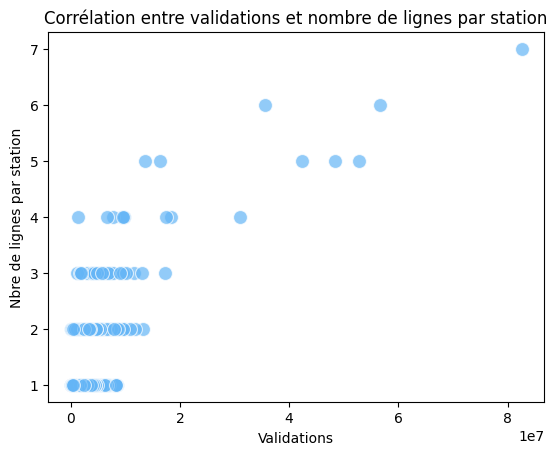

In [22]:
# Corrélation entre nombre de validations et nombre de lignes correspondance par station.

plt.figure()

sns.scatterplot(validations_lignes_df, x="nb_vald", y="nb_lignes", color="#64B5F6", alpha=0.7, s=100)

plt.title("Corrélation entre validations et nombre de lignes par station")
plt.xlabel("Validations")
plt.ylabel("Nbre de lignes par station")

plt.show()